# Grouped Category Importance -- Environmental + Silvicultural Attribution

This notebook replaces `env_variable_importance.ipynb` (see the note at the top of that file).
It covers the same ground, plus stand-structure (silviculture) variables like canopy cover and
thinning history, all in one combined feature set.

The methods below go in order, from simplest to most advanced:

1. **Correlations** -- do variables in the same category agree with each other? Do variables in
   different categories secretly track each other?
2. **Elastic Net** -- a simple model. For each variable: does it push growth up or down, and by
   how much?
3. **XGBoost** -- a more powerful model that can capture curves and thresholds, not just straight
   lines.
4. **Grouped permutation importance** -- a safer way to check importance than SHAP, when
   variables are correlated.
5. **SHAP** -- explains which variables the model relies on, and in which direction, with its own
   known weakness under correlation.
6. **Spatial cross-validation** -- proof that testing on a random split (instead of a spatial
   one) makes the model look better than it really is.
7. **Moran's I before and after** -- does removing a category leave behind more unexplained
   spatial pattern in the leftover errors?

Every chart below either explains in plain words what it shows, or tells you exactly how to read
it -- so you can check the conclusion yourself against what's actually on the screen.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import spearmanr

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 60)

PRIMARY_COHORT = "4survey"
SECONDARY_COHORT = "6survey"

print("project_root:", project_root)


project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


## 0. Load data and reproduce the spatial split

In [2]:
from models.common.metrics import compute_metrics
from models.common.splits import (
    SPATIAL_BLOCK_COL, SPATIAL_BUFFER_METRES, plot_level_split, spatial_block_split,
)
from models.xgb_environmental.data import load_plots_for_cohort
from models.xgb_environmental.xgb_environmental import (
    ALL_FEATURE_COLUMNS, FEATURE_PROVENANCE,
    fit_with_columns as xgb_fit, predict_with_columns as xgb_predict, compute_shap_values,
)
from models.elasticnet_environmental.elasticnet_environmental import (
    CATEGORICAL_COLUMNS as ELASTICNET_CATEGORICAL_COLUMNS,
    drop_rows_with_missing_features,
    fit_with_columns as elasticnet_fit,
    get_coefficients_table,
    predict_with_columns as elasticnet_predict,
)
from models.xgb_environmental.grouped_analysis import (
    CATEGORY_GROUPS,
    category_morans_i_before_after,
    cross_category_correlations,
    grouped_permutation_importance,
)

plots_df = load_plots_for_cohort(PRIMARY_COHORT)
plots_df["split"] = spatial_block_split(
    plots_df, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES, seed=42,
)
train_df = plots_df[plots_df["split"] == "train"]
val_df = plots_df[plots_df["split"] == "val"]
test_df = plots_df[plots_df["split"] == "test"]

print(f"Reproduced spatial split: {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test rows")
print(f"Feature set: {len(ALL_FEATURE_COLUMNS)} variables across {len(CATEGORY_GROUPS)} categories:")
for category_name, columns in CATEGORY_GROUPS.items():
    print(f"  {category_name}: {columns}")


  Buffer: 3,284 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
Reproduced spatial split: 38,782 train / 14,990 val / 14,710 test rows
Feature set: 38 variables across 7 categories:
  terrain: ['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'solar_radiation_index', 'soil_depth_proxy', 'frost_hollow_flag', 'ceh_twi']
  wind: ['gwa_wind_speed_10m', 'topex', 'windward_topex', 'whcl']
  soil_site: ['soilgrids_ph', 'ceh_pedotope', 'ceh_subsurface_drainage', 'ceh_textural_composition', 'dist_to_watercourse']
  climate: ['haduk_tas_2021_mean', 'chelsa_bio1_celsius', 'chelsa_gdd5_degc', 'chelsa_bio12_precip_mm']
  spatial_position_edge_effects: ['dist_to_cpmt_boundary', 'dist_to_forest_perimeter', 'dist_to_scpt_boundary', 'dist_to_block_boundary', 'cpmt_compactness_ratio', 'dist_to_road']
  stand_structure: ['CanopyCover', 'Thin', 'time_since_thinning', 'ti

**How val and test are used in this notebook**: VAL is used every time a decision or comparison
is made below (grouped permutation importance, Moran's I, the spatial-CV check). TEST is only
looked at once -- right after XGBoost is fit in section 3 -- to report one final, honest score.
It's never touched again after that.


## 1. Correlations and simple relationships

Two questions worth asking before fitting any model:

- **Within a category**: do variables meant to measure the same thing actually agree with each
  other? (e.g. do the different terrain variables move together in a sensible way?)
- **Across categories**: does one category secretly track another? For example, does elevation
  (a terrain variable) also happen to track wind exposure? This matters later -- in sections 4
  and 7, a category can look unimportant just because a DIFFERENT, correlated category is
  quietly doing its job instead.


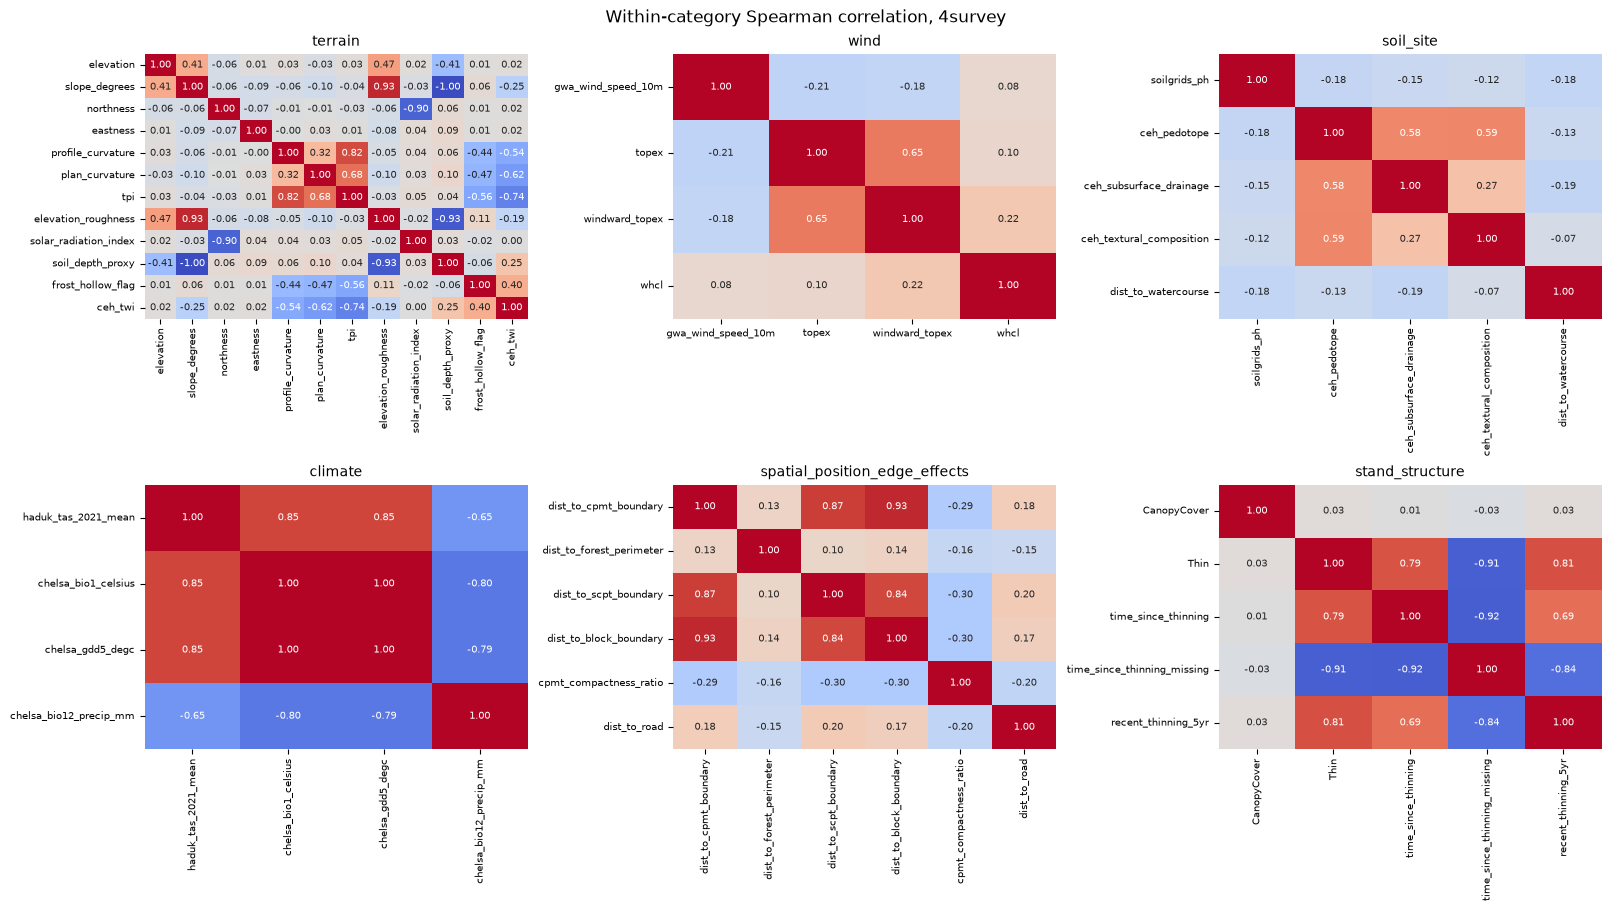

In [3]:
# Within-category correlation heatmaps -- one per category with 2+ variables.
categories_to_plot = [name for name, cols in CATEGORY_GROUPS.items() if len(cols) >= 2]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for ax, category_name in zip(axes.ravel(), categories_to_plot):
    columns = CATEGORY_GROUPS[category_name]
    corr = plots_df[columns].corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, cbar=False, annot_kws={"size": 7})
    ax.set_title(category_name, fontsize=10)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(categories_to_plot):]:
    ax.axis("off")
fig.suptitle(f"Within-category Spearman correlation, {PRIMARY_COHORT}", fontsize=12)
plt.show()


**How to read this**: a dark red or dark blue square (off the diagonal) means two variables in
the SAME category move together strongly. Some of that is expected -- e.g. `soil_depth_proxy` is
just `-slope_degrees` by definition, not a new finding. A category that's mostly pale, with
values near zero, means its variables are each measuring something genuinely different from each
other.


In [4]:
cross_category = cross_category_correlations(plots_df, threshold=0.3)
print(f"{len(cross_category)} cross-category pairs at |rho| >= 0.3")
cross_category.head(15)


81 cross-category pairs at |rho| >= 0.3


,category_a,variable_a,category_b,variable_b,rho,p_value
14,terrain,elevation,climate,chelsa_gdd5_degc,-0.942868,0.0
13,terrain,elevation,climate,chelsa_bio1_celsius,-0.940454,0.0
12,terrain,elevation,climate,haduk_tas_2021_mean,-0.876857,0.0
15,terrain,elevation,climate,chelsa_bio12_precip_mm,0.788554,0.0
7,terrain,elevation,soil_site,soilgrids_ph,-0.649153,0.0
42,soil_site,soilgrids_ph,climate,chelsa_bio12_precip_mm,-0.630579,0.0
41,soil_site,soilgrids_ph,climate,chelsa_gdd5_degc,0.626797,0.0
40,soil_site,soilgrids_ph,climate,chelsa_bio1_celsius,0.621975,0.0
67,climate,chelsa_bio12_precip_mm,stand_structure,Thin,-0.606544,0.0
39,soil_site,soilgrids_ph,climate,haduk_tas_2021_mean,0.594074,0.0


**How to read this**: each row is a real, measured correlation between two variables from
DIFFERENT categories -- not just something that sounds plausible. For example, `elevation`
(terrain) correlates with `soilgrids_ph` and `gwa_wind_speed_10m` (soil and wind) -- higher
ground here tends to have different soil chemistry and more regional wind. But this does NOT
mean terrain and wind always go together: `topex` and `windward_topex` (two other wind
measurements, calculated locally rather than from a regional model) barely correlate with
elevation at all. So "elevation tracks wind" is only true for ONE way of measuring wind, not
wind in general. Keep this table in mind for sections 4 and 7 below: if a category looks
unimportant there, check this table first -- it might really not matter, or a correlated
category here might be quietly covering for it.


## 2. Elastic Net -- a simple, easy-to-read check

Before fitting, every continuous variable is rescaled onto the same footing (mean 0, standard
deviation 1) -- called "standardizing". This means each fitted number (a coefficient) can be
read the same way for every variable: "this many metres of growth, per one standard-deviation
change in this variable". Three of the soil variables (`ceh_pedotope`, `ceh_subsurface_drainage`,
`ceh_textural_composition`) are just category ID numbers, not a real scale -- category 3 isn't
"more" than category 1 in any meaningful sense. So these three are split into separate yes/no
columns first (one-hot encoding), instead of being fed in as if they were an ordinary number.

`ElasticNetCV` picks its own penalty strength automatically, by testing a few options only on the
training data -- so this step never looks at val or test.

A small number of rows (under 1%) are missing a value for one of the variables and are dropped
before fitting -- Elastic Net can't handle a missing value the way XGBoost (section 3) can.


In [5]:
elasticnet_train_df = drop_rows_with_missing_features(train_df, ALL_FEATURE_COLUMNS)
elasticnet_val_df = drop_rows_with_missing_features(val_df, ALL_FEATURE_COLUMNS)
elasticnet_test_df = drop_rows_with_missing_features(test_df, ALL_FEATURE_COLUMNS)

elasticnet_fitted = elasticnet_fit(elasticnet_train_df, ALL_FEATURE_COLUMNS)
print(f"ElasticNetCV picked alpha={elasticnet_fitted['model'].alpha_:.4f}, l1_ratio={elasticnet_fitted['model'].l1_ratio_:.2f}")

elasticnet_val_predictions = elasticnet_predict(elasticnet_val_df, elasticnet_fitted, ALL_FEATURE_COLUMNS)
elasticnet_val_r2 = compute_metrics(elasticnet_val_df["mean_cr_residual"].values, elasticnet_val_predictions)["r2"]
print(f"Elastic Net val R2: {elasticnet_val_r2:.3f}")

elasticnet_coefficients = get_coefficients_table(elasticnet_fitted)
elasticnet_coefficients.head(15).to_frame()


  Dropped 241 of 38782 rows with a missing value in one of 38 features
  Dropped 81 of 14990 rows with a missing value in one of 38 features
  Dropped 146 of 14710 rows with a missing value in one of 38 features


ElasticNetCV picked alpha=0.0033, l1_ratio=1.00
Elastic Net val R2: 0.700


,coefficient
elevation,-2.623781
neighbour_mean_height,2.444834
neighbour_height_differential,2.372581
time_since_thinning_missing,-2.333425
time_since_thinning,-1.840047
ceh_pedotope_12.0,-1.101152
chelsa_gdd5_degc,-0.928221
Thin,-0.658884
solar_radiation_index,0.483938
slope_degrees,0.470230


**How to read this**: the sign tells you the direction. Positive means the variable pushes
growth UP (taller than the standard growth curve predicts); negative means it pushes growth
DOWN. The size of the number tells you how much. If a variable's coefficient is exactly 0.0, the
model decided it added nothing once every other variable was already included.


## 3. XGBoost -- a stronger, more flexible model

Plain XGBoost, default settings (not yet tuned -- same honesty as the other baseline models in
this repo). Unlike Elastic Net, XGBoost can automatically find curves, thresholds, and
combinations between variables, without being told where to look.


In [6]:
xgb_model = xgb_fit(train_df, ALL_FEATURE_COLUMNS)

xgb_val_predictions = xgb_predict(val_df, xgb_model, ALL_FEATURE_COLUMNS)
xgb_val_r2 = compute_metrics(val_df["mean_cr_residual"].values, xgb_val_predictions)["r2"]

# TEST is read here, ONCE, as the final headline number -- not used again below to decide
# anything (every ranking/comparison from here on uses val_df only).
xgb_test_predictions = xgb_predict(test_df, xgb_model, ALL_FEATURE_COLUMNS)
xgb_test_metrics = compute_metrics(test_df["mean_cr_residual"].values, xgb_test_predictions)

print(f"Elastic Net val R2: {elasticnet_val_r2:.3f}")
print(f"XGBoost    val R2: {xgb_val_r2:.3f}")
print(f"XGBoost    test R2: {xgb_test_metrics['r2']:.3f}, RMSE: {xgb_test_metrics['rmse']:.3f}  (final, headline number)")


Elastic Net val R2: 0.700
XGBoost    val R2: 0.734
XGBoost    test R2: 0.629, RMSE: 3.410  (final, headline number)


**How to read this**: if XGBoost's score is only a little better than Elastic Net's, the real
relationships in this data are mostly close to straight lines -- there isn't much extra, curved
structure for a more powerful model to find. If XGBoost is a lot better, that's a sign of real
thresholds or interactions worth capturing with a non-linear model (and eventually Env-PINN).
Either way, Elastic Net's score is a useful baseline: it shows how much of XGBoost's apparent
skill is really about complex patterns, versus how much any reasonable model would get from this
data.


## 4. Grouped permutation importance -- a safer importance ranking

SHAP (section 5) has a known weak spot: if two variables are correlated, a tree can split on
EITHER one to capture the same pattern -- and which one it happens to pick isn't necessarily the
"true" answer, just an accident of how the trees grew. Grouped permutation importance asks a
more direct question instead: take a whole category, shuffle all its variables together (using
the same shuffled row order for every column in that category, so their relationships to EACH
OTHER stay real -- only their link to the answer, and to other categories, is broken), then check
how much the ALREADY-FITTED XGBoost model's score drops. No refitting needed -- this measures how
much the model, as it already is, actually depends on that category's real values.


In [7]:
permutation_rows = []
for category_name, category_columns in CATEGORY_GROUPS.items():
    result = grouped_permutation_importance(
        xgb_model, val_df, ALL_FEATURE_COLUMNS, category_columns, xgb_predict, n_repeats=20,
    )
    permutation_rows.append({"category": category_name, **result})

permutation_df = pd.DataFrame(permutation_rows).sort_values("mean_r2_drop", ascending=False)
permutation_df


,category,baseline_r2,mean_r2_drop,std_r2_drop,n_repeats
6,neighbour_spatial_lag,0.734319,1.177022,0.009935,20
3,climate,0.734319,0.117019,0.002836,20
5,stand_structure,0.734319,0.110929,0.003969,20
0,terrain,0.734319,0.097397,0.002618,20
4,spatial_position_edge_effects,0.734319,0.054858,0.002875,20
2,soil_site,0.734319,0.036205,0.001610,20
1,wind,0.734319,0.022700,0.002162,20


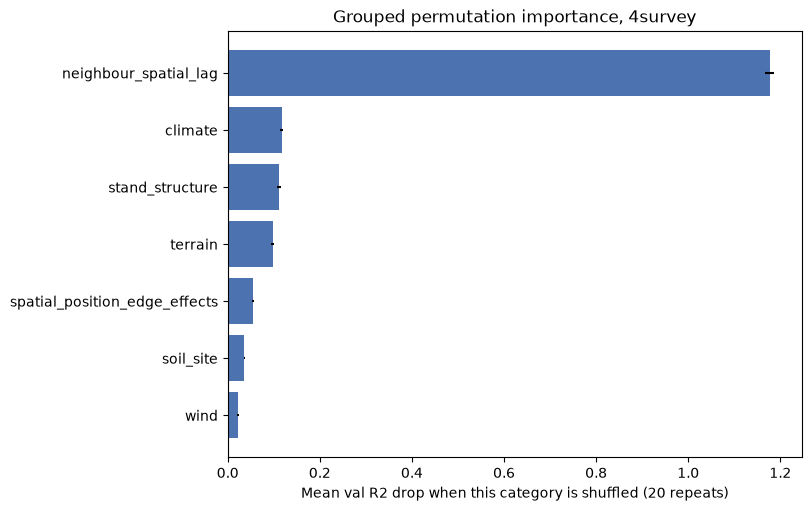

In [8]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.barh(permutation_df["category"], permutation_df["mean_r2_drop"], xerr=permutation_df["std_r2_drop"], color="#4c72b0")
ax.invert_yaxis()
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Mean val R2 drop when this category is shuffled (20 repeats)")
ax.set_title(f"Grouped permutation importance, {PRIMARY_COHORT}")
plt.show()


**How to read this**: a bigger bar means the model's score drops more when that category is
shuffled -- so the model relies on it more. A bar at or near zero means shuffling that category
barely changes anything -- the model isn't really using it. If a result here looks surprising,
check section 1's cross-category correlation table: a category might genuinely not matter, or
its signal might be getting picked up through a correlated category instead.


## 5. SHAP -- explains direction and effect

This uses TreeSHAP specifically (`shap.TreeExplainer`) -- the fast, exact version of SHAP built
for tree models like XGBoost. (A future neural-network model, like Env-PINN, would use a
different SHAP variant instead -- DeepSHAP or GradientSHAP -- built for that kind of model.)

Computed using only the train and val rows, never test. Earlier in this project, SHAP was
accidentally computed using ALL rows including test -- a real bug, since it let the "held-out"
test set be looked at before the one honest, final evaluation. That's fixed now.

**Read this with its own caveat in mind, not as a final answer**: under correlated variables,
SHAP can rank a variable as important just because the model happened to split on it rather than
its correlated partner -- not because it's genuinely more useful for prediction. Section 4's
permutation importance is the safer cross-check.


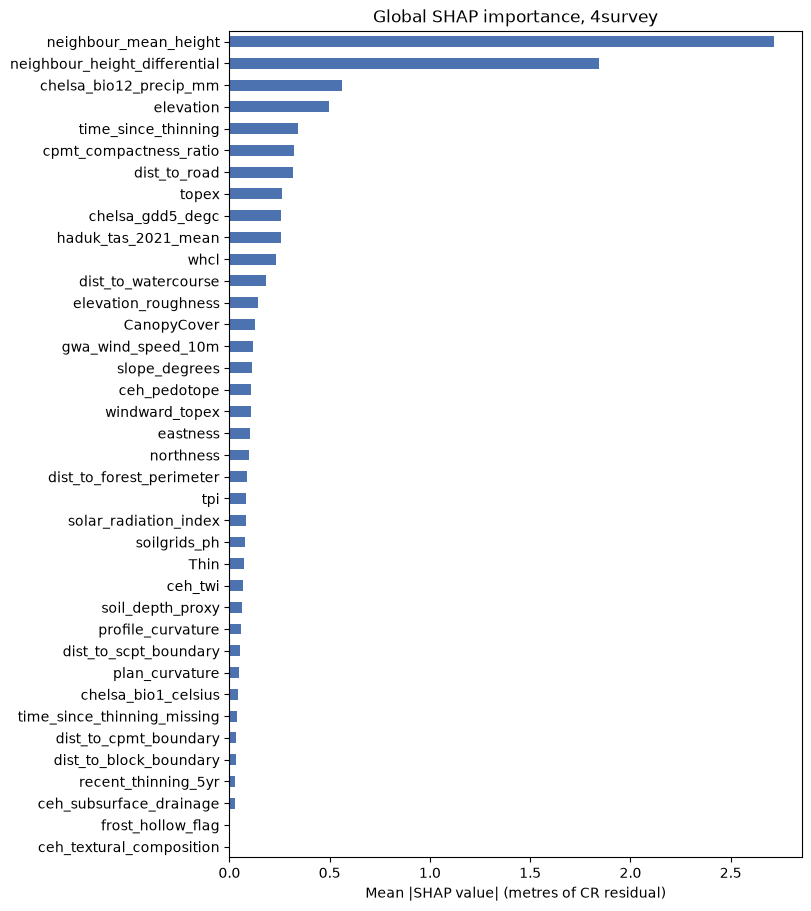

neighbour_mean_height            2.717958
neighbour_height_differential    1.844755
chelsa_bio12_precip_mm           0.559940
elevation                        0.494616
time_since_thinning              0.340597
cpmt_compactness_ratio           0.323683
dist_to_road                     0.316354
topex                            0.262391
chelsa_gdd5_degc                 0.256477
haduk_tas_2021_mean              0.256139
whcl                             0.234320
dist_to_watercourse              0.181407
elevation_roughness              0.143657
CanopyCover                      0.129363
gwa_wind_speed_10m               0.116147
dtype: float32

In [9]:
train_and_val_df = plots_df[plots_df["split"].isin(["train", "val"])]
shap_df = compute_shap_values(xgb_model, train_and_val_df, "all_environmental")

mean_abs_shap = shap_df.drop(columns=["identification"]).abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9), constrained_layout=True)
mean_abs_shap.plot.barh(ax=ax, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (metres of CR residual)")
ax.set_title(f"Global SHAP importance, {PRIMARY_COHORT}")
plt.show()

mean_abs_shap.head(15)


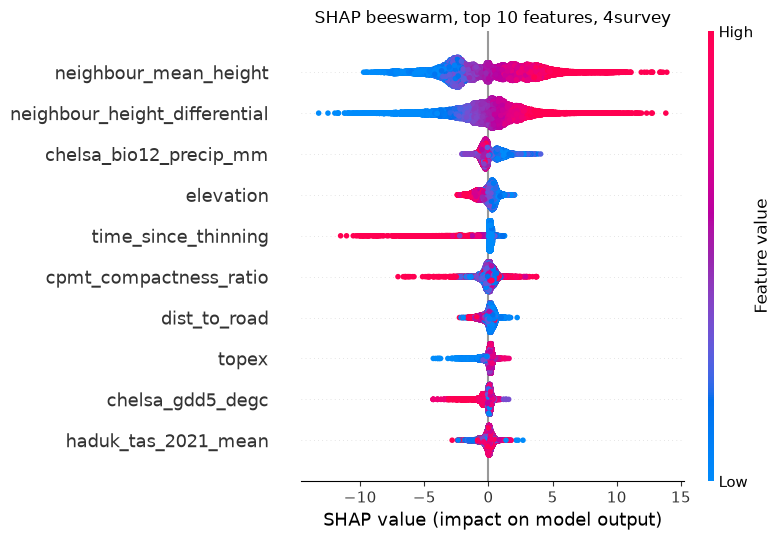

In [10]:
top_features = mean_abs_shap.head(10).index.tolist()
shap.summary_plot(
    shap_df[top_features].values,
    train_and_val_df.set_index("identification").loc[shap_df["identification"], top_features],
    feature_names=top_features, show=False,
)
plt.title(f"SHAP beeswarm, top 10 features, {PRIMARY_COHORT}")
plt.tight_layout()
plt.show()


**How to read the beeswarm**: each dot is one plot. Its colour is that plot's own value for the
variable (red = high, blue = low). Its left-right position shows how much that pushed the
prediction up (right) or down (left). If the colours form a clean gradient (all red on one side,
all blue on the other), the relationship is simple and consistent. If the colours are mixed up,
the relationship isn't simple -- check the ALE chart below before trusting any "this variable
pushes growth up/down" claim from this plot alone.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


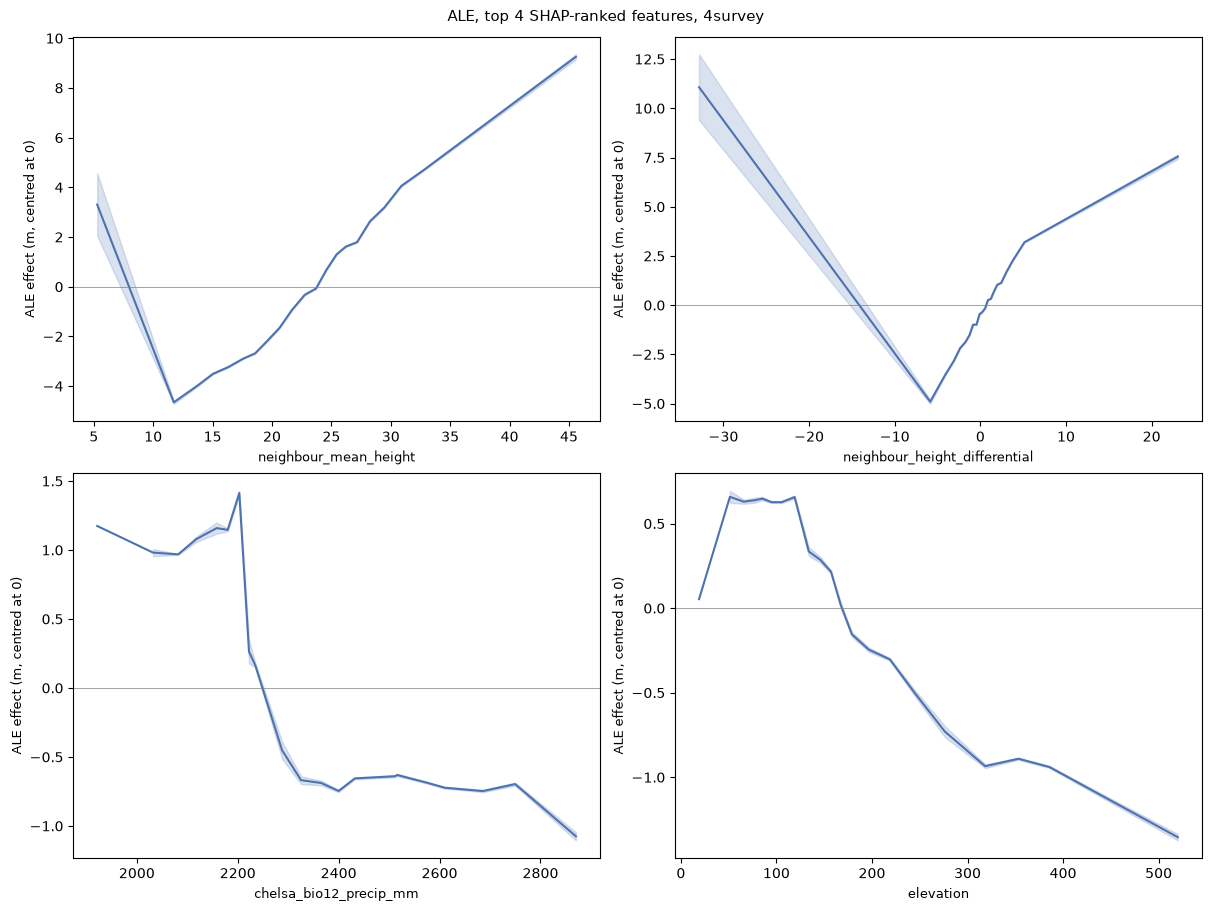

In [11]:
from PyALE import ale

ale_model = xgb_model
X_for_ale = train_df[ALL_FEATURE_COLUMNS]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, feature_name in zip(axes.ravel(), top_features[:4]):
    ale_effect = ale(
        X=X_for_ale, model=ale_model, feature=[feature_name], grid_size=20,
        include_CI=True, plot=False,
    )
    ax.plot(ale_effect.index, ale_effect["eff"], color="#4c72b0")
    ax.fill_between(
        ale_effect.index, ale_effect["lowerCI_95%"], ale_effect["upperCI_95%"],
        color="#4c72b0", alpha=0.2,
    )
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(feature_name, fontsize=9)
    ax.set_ylabel("ALE effect (m, centred at 0)", fontsize=9)
fig.suptitle(f"ALE, top 4 SHAP-ranked features, {PRIMARY_COHORT}", fontsize=11)
plt.show()


**How to read this**: ALE shows the actual SHAPE of each relationship. A straight diagonal line
means a simple, linear effect (matching what Elastic Net's coefficient already said in section
2). A flat line that suddenly jumps up or down means a threshold -- nothing happens until a
certain point, then it does. A wiggly line that goes up, then down, then up again is a warning
sign: it usually means the model has picked up something more complicated than a clean cause and
effect -- similar to how `Age` was found to be tracking a fitting artefact rather than a real
effect (see progress_notes.md).


## 6. Spatial cross-validation -- a fair test for spatial data

Every result above (and section 7 below) uses `spatial_block_split()` -- whole forestry
compartments held out together, with a 60m buffer removing any train plot too close to a
held-out one. This matters because neighbouring plots share near-identical terrain/wind/soil
conditions: a RANDOM plot-level split can let a model "cheat" by placing near-duplicates of a
test plot's conditions directly in training, making it look like it generalises when it has
really just memorised local conditions. Demonstrated directly below, not just asserted.

**This section builds a second, completely separate, throwaway comparison** -- a fresh model fit
on a plain random 60/20/20 split of the whole dataset by individual plot (`plot_level_split()`),
ignoring compartment/geography entirely. It is NOT nested inside, or combined with, the real
spatial split used everywhere else in this notebook -- it's an independent "what if we'd naively
used a random split instead" experiment, run once here purely to measure the inflation directly,
then thrown away. Its model and predictions are never saved or referenced again after this
section.


In [12]:
from models.common.splits import plot_level_split

random_split_labels = plot_level_split(plots_df, plot_col="identification", seed=42)
plots_df_random = plots_df.copy()
plots_df_random["random_split"] = random_split_labels

random_train_df = plots_df_random[plots_df_random["random_split"] == "train"]
random_test_df = plots_df_random[plots_df_random["random_split"] == "test"]

random_split_model = xgb_fit(random_train_df, ALL_FEATURE_COLUMNS)
random_split_predictions = xgb_predict(random_test_df, random_split_model, ALL_FEATURE_COLUMNS)
random_split_r2 = compute_metrics(random_test_df["mean_cr_residual"].values, random_split_predictions)["r2"]

print(f"Spatial-block test R2 (section 3, the honest number): {xgb_test_metrics['r2']:.3f}")
print(f"Random plot-level test R2 (same model, same data, different split): {random_split_r2:.3f}")
print(f"Inflation from using a random split instead of a spatial one: {random_split_r2 - xgb_test_metrics['r2']:+.3f}")


Spatial-block test R2 (section 3, the honest number): 0.629
Random plot-level test R2 (same model, same data, different split): 0.887
Inflation from using a random split instead of a spatial one: +0.258


**How to read this**: if the random-split score is a lot higher than the spatial-split score,
that gap is exactly the amount of "fake" generalisation a random split would have reported --
performance that disappears once nearby plots are kept out of each other's way. This is why
every real number in this notebook uses the spatial split, not this random one.


## 7. Moran's I before and after -- is the spatial pattern actually explained?

A different question to everything above. Not "how important is this category for prediction",
but "once this category is removed, are the leftover errors MORE clustered in space than
before?" Moran's I is a number that answers this: close to 0 means no real spatial pattern in
the errors; clearly above 0 (with a small p-value) means nearby plots really do have similar
errors, more than chance alone would explain.

This reuses an existing tool in the repo (`global_morans_i()`), which first works out the right
distance to test at (using a semivariogram -- a curve-fitting step that finds how far apart two
plots need to be before their values stop being related), rather than guessing a distance.

Unlike section 4, this refits a brand-new model for each category removed, rather than reusing
one model and shuffling its inputs -- because this needs REAL errors from a model that never saw
that category at all.


In [13]:
morans_i_df = category_morans_i_before_after(train_df, val_df, xgb_fit, xgb_predict)
morans_i_df


,category_removed,morans_i,morans_i_p,variogram_status,variogram_range_m
0,(none -- full model),0.196548,0.005,resolved,630.016218
1,terrain,0.262957,0.005,resolved,694.623203
2,wind,0.237981,0.005,resolved,602.444609
3,soil_site,0.250405,0.005,resolved,697.021715
4,climate,0.250997,0.005,resolved,676.639413
5,spatial_position_edge_effects,0.248040,0.005,resolved,658.305391
6,stand_structure,0.237839,0.005,resolved,662.912500
7,neighbour_spatial_lag,0.226356,0.005,resolved,1611.024233


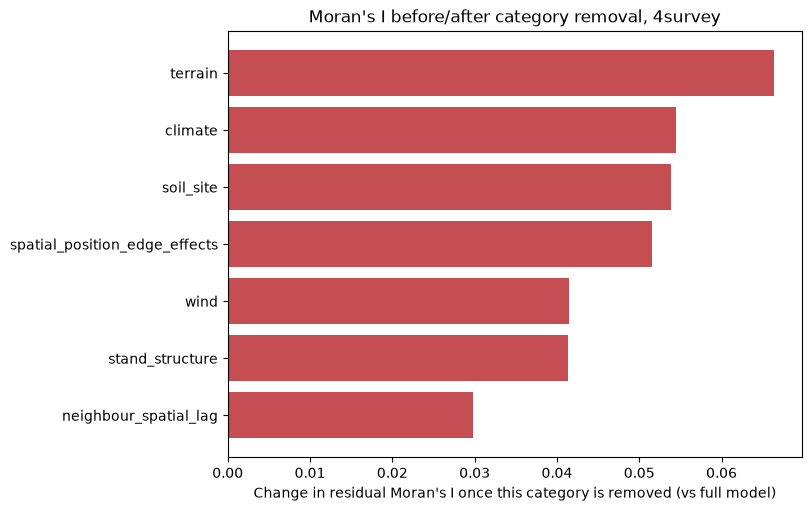

Full model residual Moran's I: 0.197 (p=0.005)


,category_removed,morans_i,morans_i_p,morans_i_change
1,terrain,0.262957,0.005,0.066409
4,climate,0.250997,0.005,0.054449
3,soil_site,0.250405,0.005,0.053857
5,spatial_position_edge_effects,0.248040,0.005,0.051492
2,wind,0.237981,0.005,0.041433
6,stand_structure,0.237839,0.005,0.041291
7,neighbour_spatial_lag,0.226356,0.005,0.029809


In [14]:
full_model_row = morans_i_df[morans_i_df["category_removed"] == "(none -- full model)"].iloc[0]
category_rows = morans_i_df[morans_i_df["category_removed"] != "(none -- full model)"].copy()
category_rows["morans_i_change"] = category_rows["morans_i"] - full_model_row["morans_i"]
category_rows = category_rows.sort_values("morans_i_change", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.barh(category_rows["category_removed"], category_rows["morans_i_change"], color="#c44e52")
ax.invert_yaxis()
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Change in residual Moran's I once this category is removed (vs full model)")
ax.set_title(f"Moran's I before/after category removal, {PRIMARY_COHORT}")
plt.show()

print(f"Full model residual Moran's I: {full_model_row['morans_i']:.3f} (p={full_model_row['morans_i_p']:.3f})")
category_rows[["category_removed", "morans_i", "morans_i_p", "morans_i_change"]]


**How to read this**: the full model's own Moran's I (printed above) is the starting point -- if
it's already close to 0, or not statistically significant, the model has already accounted for
most of the real spatial pattern. For each category: a POSITIVE change means removing it made
the errors MORE clustered than before -- real spatial pattern that category was explaining is
now left unexplained. A change near zero means that category wasn't responsible for the spatial
pattern. Compare this to section 4's results: a category can matter a lot for raw accuracy
without being the one responsible for spatial clustering, or the other way round -- these are
genuinely different questions, and they don't have to agree.


## 8. Closing summary -- cross-checking every method against each other

This combines Elastic Net's coefficients (section 2), grouped permutation importance (section
4), and SHAP (section 5) into one table, one row per category -- so it's easy to see where the
methods agree and where they don't. This is the same kind of cross-check that caught
`elevation`'s misleading SHAP result in the earlier per-variable notebook (high SHAP importance,
but removing it actually improved the model's real score). Where methods disagree here, that
disagreement is itself worth reporting -- not something to quietly resolve by picking whichever
number looks best.


In [15]:
def elasticnet_category_summary(coefficients, category_columns):
    total = 0.0
    for column in category_columns:
        if column in ELASTICNET_CATEGORICAL_COLUMNS:
            matching = coefficients[coefficients.index.str.startswith(column + "_")]
            total += matching.abs().sum()
        else:
            total += abs(coefficients.get(column, 0.0))
    return total

summary_rows = []
for category_name, category_columns in CATEGORY_GROUPS.items():
    summary_rows.append({
        "category": category_name,
        "elasticnet_summed_abs_coefficient": elasticnet_category_summary(elasticnet_coefficients, category_columns),
        "mean_abs_shap_summed": mean_abs_shap.reindex(category_columns).sum(),
        "permutation_mean_r2_drop": permutation_df.set_index("category").loc[category_name, "mean_r2_drop"],
        "morans_i_change": category_rows.set_index("category_removed").loc[category_name, "morans_i_change"],
    })

summary_df = pd.DataFrame(summary_rows)
for rank_column in ["elasticnet_summed_abs_coefficient", "mean_abs_shap_summed", "permutation_mean_r2_drop"]:
    summary_df[rank_column.replace("_summed", "").replace("_mean_r2_drop", "") + "_rank"] = (
        summary_df[rank_column].rank(ascending=False).astype(int)
    )
summary_df.sort_values("permutation_mean_r2_drop", ascending=False)


,category,elasticnet_summed_abs_coefficient,mean_abs_shap_summed,permutation_mean_r2_drop,morans_i_change,elasticnet_abs_coefficient_rank,mean_abs_shap_rank,permutation_rank
6,neighbour_spatial_lag,4.817415,4.562713,1.177022,0.029809,2,1,1
3,climate,1.280099,1.116078,0.117019,0.054449,5,3,2
5,stand_structure,5.464938,0.606452,0.110929,0.041291,1,6,3
0,terrain,4.547373,1.352650,0.097397,0.066409,3,2,4
4,spatial_position_edge_effects,0.746649,0.844020,0.054858,0.051492,6,4,5
2,soil_site,2.123478,0.390675,0.036205,0.053857,4,7,6
1,wind,0.437856,0.719773,0.022700,0.041433,7,5,7


**How to read the ranks**: three separate methods each rank every category from 1st to 7th
(Elastic Net's coefficients, SHAP, and grouped permutation importance). If all three roughly
agree on a category, that's a much stronger basis for a conclusion than trusting any one method
alone. If SHAP ranks a category high but permutation importance ranks it low, be suspicious of
SHAP's number -- permutation importance is answering a more direct question (does the model's
real score actually depend on this), which SHAP's mechanism can get wrong when variables are
correlated.

**What this notebook does NOT tell you**: none of Elastic Net, XGBoost, SHAP, or permutation
importance can say whether a variable actually CAUSES more or less growth -- they all describe
what the fitted model relies on, not a proven cause-and-effect. Double/Debiased ML and BART are
the methods that could answer that, and remain planned future work, not built yet (see
`env_variable_importance.ipynb` section 6 for the full reasoning).

**What this notebook does NOT build**: Env-PINN itself (the real next step, using whichever
categories/variables come out of this analysis) and the live interactive map (a design decision,
deliberately left for later).
